# Importing data and preproceesing

In [30]:
import pandas as pd
import numpy as np

data=pd.read_csv("cylinder.csv")

In [31]:
data=data.rename(columns={"U:0":"U_x","U:1":"U_y","U:2":"U_z","Gradient:0":"dU/dx","Gradient:1":"dU/dy","Gradient:3":"dV/dx","Gradient:4":"dV/dy"})
data=data.drop(["Points:0","Points:1","Points:2"],axis=1)

In [32]:
data

,dU/dx,dU/dy,Gradient:2,dV/dx,dV/dy,Gradient:5,Gradient:6,Gradient:7,Gradient:8,U_x,U_y,U_z,k,nut,omega,p
0,0.000231,0.000000,0.0,-0.000145,0.000000,0.0,6.875100e-14,0.000000e+00,0.0,1.0000,0.000000,0.000000e+00,0.010000,0.010000,1.00000,0.235330
1,0.000458,0.000106,0.0,-0.000141,-0.000375,0.0,1.347800e-13,3.002100e-14,0.0,1.0000,-0.000010,4.583400e-15,0.009918,0.009994,0.99242,0.235330
2,0.000793,0.000365,0.0,-0.000041,-0.000803,0.0,-3.439000e-14,2.857700e-14,0.0,1.0001,-0.000019,1.797100e-14,0.009860,0.009989,0.98706,0.235330
3,0.000892,0.000694,0.0,0.000071,-0.000835,0.0,-2.502500e-13,2.787500e-14,0.0,1.0001,-0.000015,-1.871900e-18,0.009802,0.009984,0.98176,0.235300
4,0.000858,0.001037,0.0,0.000094,-0.000834,0.0,2.564100e-14,4.916300e-14,0.0,1.0002,-0.000009,-1.539500e-14,0.009745,0.009980,0.97651,0.235260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21315,0.050117,0.311130,0.0,-0.002085,-0.033638,0.0,0.000000e+00,7.190100e-17,0.0,1.3316,0.001934,0.000000e+00,0.032801,0.026924,1.21830,-0.005240
21316,0.045120,0.289850,0.0,-0.002048,-0.030714,0.0,0.000000e+00,1.595500e-17,0.0,1.3370,0.001706,0.000000e+00,0.033219,0.027295,1.21700,-0.002684
21317,0.042033,0.269200,0.0,-0.001986,-0.028569,0.0,0.000000e+00,0.000000e+00,0.0,1.3419,0.001466,0.000000e+00,0.033589,0.027642,1.21520,-0.000470
21318,0.030887,0.243290,0.0,-0.001321,-0.026672,0.0,0.000000e+00,0.000000e+00,0.0,1.3466,0.001252,0.000000e+00,0.033887,0.027941,1.21280,0.000798


In [33]:
data["k/omega"]=data["k"]/data["omega"]

In [34]:
data["omega/k"]=data["omega"]/data["k"]

In [35]:
data["k*omega"]=data['k']*data['omega']
data["k**2/omega**2"]=data['k']

# Main SINDy Algorithm Implementation Code 

In [36]:
# Main SINDy Algorithm Implementation code

import pysindy as ps
from pysindy.feature_library import CustomLibrary
from pysindy.optimizers import STLSQ
from sklearn.preprocessing import StandardScaler

  # contains K(turbulrnt kinetic energy), e (dissiipation rate),dU/dx,dU/dy (velocity gradients) etc 


X = data[['k', 'omega',"k*omega","k/omega","omega/k"]].values
Y=data["nut"].values.reshape(-1,1)  # contains nu_t that is turbulent viscosity actual value

scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
Y_scaled = scaler_Y.fit_transform(Y)


k = data['k'].values
omega = data['omega'].values
nut = data['nut'].values   # target


library_functions = [
    lambda x: x,
    lambda x: x**2,
    lambda x,y: x**2/ (y**2),
    lambda x, y: x/(y),
    lambda x,y:y/x
]

library_names = [
    lambda x: x,
    lambda x: x + "^2",
    lambda x,y: x+"^2"+"/"+y+"^2",
    lambda x, y: x + "/" + y,
    lambda x,y: y+"/"+x   
]

custom_library = CustomLibrary(
    library_functions=library_functions,   # a library of non linear functions will be created 
    function_names=library_names)

optimizer = STLSQ(threshold=0.1)

model = ps.SINDy(
    feature_library=custom_library,
    optimizer=optimizer)

model.fit(X_scaled,t=1,x_dot=Y_scaled)   # the data would be fitted in the model
model.print()    # the model will print the mathematical model/expression for the turbulent viscocity (nu_t)

(x0)' =  0.946 x3


# Obtained Turbulence Model from SINDy Algoruthm :
# nu_t=0.946 k/w

In [37]:
data["nut_new"]=0.946*data['k/omega']

In [38]:
data["nut"]

0        0.010000
1        0.009994
2        0.009989
3        0.009984
4        0.009980
           ...   
21315    0.026924
21316    0.027295
21317    0.027642
21318    0.027941
21319    0.028073
Name: nut, Length: 21320, dtype: float64

In [39]:
data["nut_new"]

0        0.009460
1        0.009454
2        0.009450
3        0.009445
4        0.009441
           ...   
21315    0.025470
21316    0.025822
21317    0.026148
21318    0.026432
21319    0.026558
Name: nut_new, Length: 21320, dtype: float64

# Preprocessing before plotting

In [40]:
data

,dU/dx,dU/dy,Gradient:2,dV/dx,dV/dy,Gradient:5,Gradient:6,Gradient:7,Gradient:8,U_x,...,U_z,k,nut,omega,p,k/omega,omega/k,k*omega,k**2/omega**2,nut_new
0,0.000231,0.000000,0.0,-0.000145,0.000000,0.0,6.875100e-14,0.000000e+00,0.0,1.0000,...,0.000000e+00,0.010000,0.010000,1.00000,0.235330,0.010000,100.000000,0.010000,0.010000,0.009460
1,0.000458,0.000106,0.0,-0.000141,-0.000375,0.0,1.347800e-13,3.002100e-14,0.0,1.0000,...,4.583400e-15,0.009918,0.009994,0.99242,0.235330,0.009994,100.060495,0.009843,0.009918,0.009454
2,0.000793,0.000365,0.0,-0.000041,-0.000803,0.0,-3.439000e-14,2.857700e-14,0.0,1.0001,...,1.797100e-14,0.009860,0.009989,0.98706,0.235330,0.009989,100.109536,0.009732,0.009860,0.009450
3,0.000892,0.000694,0.0,0.000071,-0.000835,0.0,-2.502500e-13,2.787500e-14,0.0,1.0001,...,-1.871900e-18,0.009802,0.009984,0.98176,0.235300,0.009984,100.157108,0.009623,0.009802,0.009445
4,0.000858,0.001037,0.0,0.000094,-0.000834,0.0,2.564100e-14,4.916300e-14,0.0,1.0002,...,-1.539500e-14,0.009745,0.009980,0.97651,0.235260,0.009980,100.205231,0.009516,0.009745,0.009441
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21315,0.050117,0.311130,0.0,-0.002085,-0.033638,0.0,0.000000e+00,7.190100e-17,0.0,1.3316,...,0.000000e+00,0.032801,0.026924,1.21830,-0.005240,0.026924,37.142160,0.039961,0.032801,0.025470
21316,0.045120,0.289850,0.0,-0.002048,-0.030714,0.0,0.000000e+00,1.595500e-17,0.0,1.3370,...,0.000000e+00,0.033219,0.027295,1.21700,-0.002684,0.027296,36.635660,0.040428,0.033219,0.025822
21317,0.042033,0.269200,0.0,-0.001986,-0.028569,0.0,0.000000e+00,0.000000e+00,0.0,1.3419,...,0.000000e+00,0.033589,0.027642,1.21520,-0.000470,0.027641,36.178511,0.040817,0.033589,0.026148
21318,0.030887,0.243290,0.0,-0.001321,-0.026672,0.0,0.000000e+00,0.000000e+00,0.0,1.3466,...,0.000000e+00,0.033887,0.027941,1.21280,0.000798,0.027941,35.789536,0.041098,0.033887,0.026432


In [41]:
data1=pd.read_csv("cylinder.csv")
data1=data1.drop(["Gradient:0","Gradient:1","Gradient:2","Gradient:3","Gradient:4","Gradient:5","Gradient:6","Gradient:7","Gradient:8","U:0","U:1","U:2","k","omega","nut","p"],axis=1)
data1["nut_new"]=data["nut_new"]

In [42]:
data1=data1.rename(columns={"Points:0":"x","Points:1":"y","Points:2":'z'})
data1.to_csv("nut_sindy.csv",index=False)

In [43]:
data1

,x,y,z,nut_new
0,-4.0000,-2.0,0.00,0.009460
1,-3.9333,-2.0,0.00,0.009454
2,-3.8667,-2.0,0.00,0.009450
3,-3.8000,-2.0,0.00,0.009445
4,-3.7333,-2.0,0.00,0.009441
...,...,...,...,...
21315,9.5429,2.0,0.01,0.025470
21316,9.6571,2.0,0.01,0.025822
21317,9.7714,2.0,0.01,0.026148
21318,9.8857,2.0,0.01,0.026432


# Plotting of results

In [44]:
import matplotlib.pyplot as plt

list_x=[]
list_y=[]

for i in range(len(data1["x"])):
    if data1["y"][i]==0:
        list_x.append(data1["x"][i])
        list_y.append(data1["nut_new"][i])


data3=pd.read_csv("cylinder.csv")

x=[]
y=[]

for i in range(len(data3["Points:0"])):
    if data3["Points:1"][i]==0:
        x.append(data3["Points:0"][i])
        y.append(data3["nut"][i])






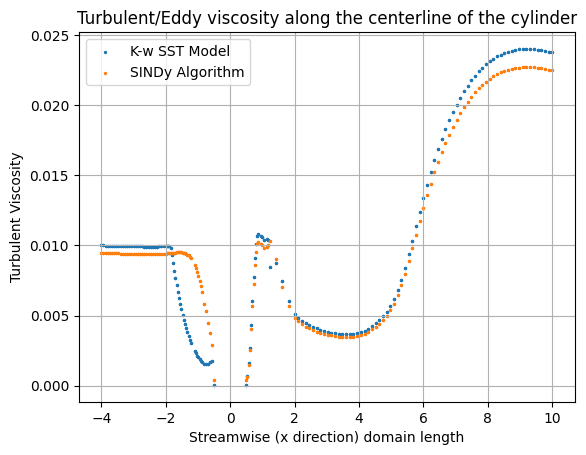

In [45]:
plt.scatter(x,y,s=2,label="K-w SST Model")
plt.scatter(list_x,list_y,s=2,label="SINDy Algorithm")
plt.grid("on")
plt.legend()
plt.title("Turbulent/Eddy viscosity along the centerline of the cylinder")
plt.xlabel("Streamwise (x direction) domain length")
plt.ylabel("Turbulent Viscosity")
plt.show()

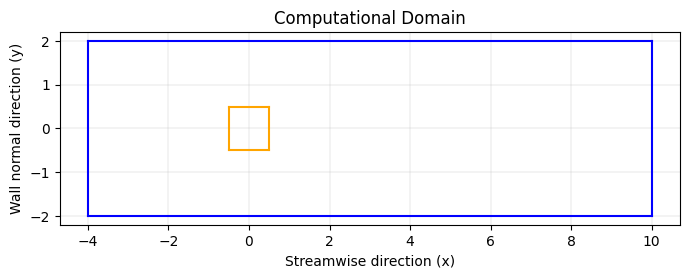

In [55]:
plt.figure(figsize=(8,2.5))
plt.plot([-4,-4],[-2,2],color="blue")
plt.plot([-4,10],[-2,-2],color="blue")
plt.plot([-4,10],[2,2],color="blue")
plt.plot([10,10],[-2,2],color="blue")
plt.plot([-0.5,0.5],[-0.5,-0.5],color="orange")
plt.plot([-0.5,-0.5],[-0.5,0.5],color="orange")
plt.plot([-0.5,0.5],[0.5,0.5],color="orange")
plt.plot([0.5,0.5],[-0.5,0.5],color="orange")
#plt.plot([-4,10],[-2,2])
#plt.plot([-4,10],[2,-2],linestyle="--")
plt.xlabel("Streamwise direction (x)")
plt.ylabel("Wall normal direction (y)")
plt.title("Computational Domain")
plt.grid("on",linewidth=0.2)
plt.show()

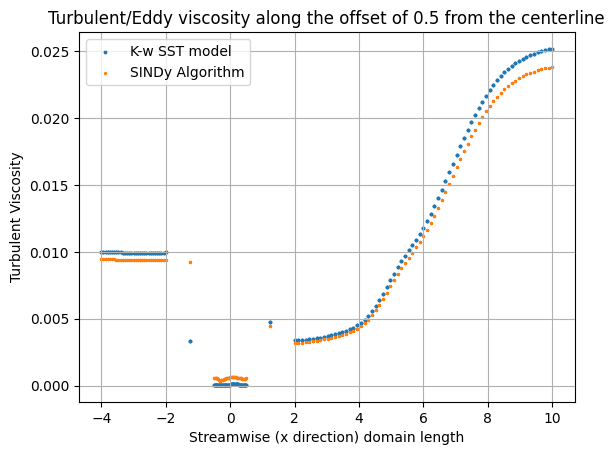

In [ ]:
# offset

list_x_o=[]
list_y_o=[]

for i in range(len(data1["x"])):
    if data1["y"][i]==0.5:
        list_x_o.append(data1["x"][i])
        list_y_o.append(data1["nut_new"][i])



x_o=[]
y_o=[]

for i in range(len(data3["Points:0"])):
    if data3["Points:1"][i]==0.5:
        x_o.append(data3["Points:0"][i])
        y_o.append(data3["nut"][i])


plt.scatter(x_o,y_o,s=3,label="K-w SST model ")
plt.scatter(list_x_o,list_y_o,s=2,label="SINDy Algorithm")
plt.grid("on")
plt.legend()
plt.title("Turbulent/Eddy viscosity along the offset of 0.5 from the centerline")
plt.xlabel("Streamwise (x direction) domain length")
plt.ylabel("Turbulent Viscosity")
plt.show()

In [ ]:
d=pd.read_csv("plot_nut_new.csv")

In [ ]:
d

,U:0,U:1,U:2,k,nut,omega,p,vtkValidPointMask,arc_length,Points:0,Points:1,Points:2
0,1.00000,0.000000,0.000000e+00,0.010000,0.010000,1.00000,0.204080,,0.000000,-4.000,2.000,0.00000
1,1.00000,0.000015,5.998900e-16,0.009983,0.009999,0.99841,0.204080,,0.014560,-3.986,1.996,0.00001
2,1.00000,0.000031,1.204000e-15,0.009966,0.009997,0.99682,0.204080,,0.029121,-3.972,1.992,0.00002
3,1.00000,0.000047,1.812400e-15,0.009949,0.009996,0.99523,0.204070,,0.043681,-3.958,1.988,0.00003
4,1.00000,0.000065,2.425000e-15,0.009931,0.009995,0.99364,0.204070,,0.058241,-3.944,1.984,0.00004
...,...,...,...,...,...,...,...,...,...,...,...,...
996,0.91405,0.001167,-8.579800e-17,0.019498,0.015154,1.28670,-0.001582,,14.502000,9.944,-1.984,0.00996
997,0.91344,0.001081,-1.050000e-16,0.019475,0.015153,1.28520,-0.001189,,14.517000,9.958,-1.988,0.00997
998,0.91284,0.000994,-1.242200e-16,0.019453,0.015152,1.28380,-0.000794,,14.531000,9.972,-1.992,0.00998
999,0.91225,0.000908,-1.434500e-16,0.019430,0.015151,1.28240,-0.000398,,14.546000,9.986,-1.996,0.00999


In [ ]:
e=pd.read_csv("plot_nut.csv")

e

,U:0,U:1,U:2,k,nut,omega,p,vtkValidPointMask,arc_length,Points:0,Points:1,Points:2
0,1.00000,0.000000,0.000000e+00,0.010000,0.010000,1.00000,0.204080,,0.000000,-4.000,2.000,0.00000
1,1.00000,0.000015,5.998900e-16,0.009983,0.009999,0.99841,0.204080,,0.014560,-3.986,1.996,0.00001
2,1.00000,0.000031,1.204000e-15,0.009966,0.009997,0.99682,0.204080,,0.029121,-3.972,1.992,0.00002
3,1.00000,0.000047,1.812400e-15,0.009949,0.009996,0.99523,0.204070,,0.043681,-3.958,1.988,0.00003
4,1.00000,0.000065,2.425000e-15,0.009931,0.009995,0.99364,0.204070,,0.058241,-3.944,1.984,0.00004
...,...,...,...,...,...,...,...,...,...,...,...,...
996,0.91405,0.001167,-8.579800e-17,0.019498,0.015154,1.28670,-0.001582,,14.502000,9.944,-1.984,0.00996
997,0.91344,0.001081,-1.050000e-16,0.019475,0.015153,1.28520,-0.001189,,14.517000,9.958,-1.988,0.00997
998,0.91284,0.000994,-1.242200e-16,0.019453,0.015152,1.28380,-0.000794,,14.531000,9.972,-1.992,0.00998
999,0.91225,0.000908,-1.434500e-16,0.019430,0.015151,1.28240,-0.000398,,14.546000,9.986,-1.996,0.00999


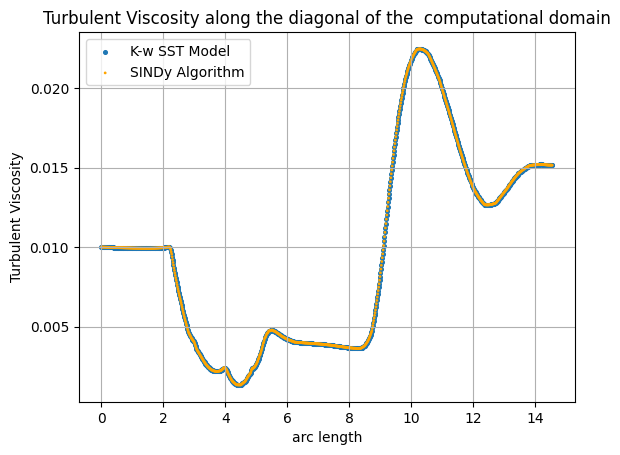

In [56]:
plt.scatter(e["arc_length"],e["nut"],label="K-w SST Model",s=7)
plt.scatter(d["arc_length"],d["nut"],label="SINDy Algorithm",s=1,linestyle="-.",color="orange")
plt.xlabel("arc length")
plt.ylabel("Turbulent Viscosity")
plt.title("Turbulent Viscosity along the diagonal of the  computational domain")
plt.legend()
plt.grid("on")
plt.show()

In [60]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(data["nut"],data1["nut_new"])

print("MSE =", mse)

MSE = 4.710358348683824e-06


In [59]:
from sklearn.metrics import r2_score

r2 = r2_score(data["nut"], data1["nut_new"])

print("R2 =", r2)

R2 = 0.8754537949890695
